In [74]:
!pip install ydata-profiling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ydata_profiling as yp
from sklearn.cluster import KMeans
from sklearn import metrics

# Análisis exploratorio 🔬🫧

In [75]:
# La fecha se carga como índice: ordena las filas y define las ventanas de tiempo,
# pero no queda como columna, así que nunca entra al modelo
df = pd.read_csv('data.csv', parse_dates=['time'], index_col='time')

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17280 entries, 2026-10-06 00:00:00+00:00 to 2026-10-07 23:59:50+00:00
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   activo                  17280 non-null  object 
 1   cpu_user                17280 non-null  float64
 2   cpu_system              17280 non-null  float64
 3   cpu_wait                17280 non-null  float64
 4   carga_1m                17280 non-null  float64
 5   memoria_used            17280 non-null  float64
 6   disco_used_frac         17280 non-null  float64
 7   disco_bytes_s           17279 non-null  float64
 8   red_bytes_s             17279 non-null  float64
 9   paginacion_s            17279 non-null  float64
 10  procesos_running        17280 non-null  float64
 11  tasa_llamadas_pedidos   17279 non-null  float64
 12  tasa_llamadas_catalogo  17279 non-null  float64
 13  tasa_errores_pedidos    17279 non-null  floa

In [77]:
df

,activo,cpu_user,cpu_system,cpu_wait,carga_1m,memoria_used,disco_used_frac,disco_bytes_s,red_bytes_s,paginacion_s,procesos_running,tasa_llamadas_pedidos,tasa_llamadas_catalogo,tasa_errores_pedidos,ref_fase,ref_uid,ref_tipo_eval
time,,,,,,,,,,,,,,,,,
2026-10-06 00:00:00+00:00,activo-do-nodo-01,0.164329,0.050100,0.002004,0.57,0.205797,0.137209,NaN,NaN,NaN,2.0,NaN,NaN,NaN,montaje,NaN,NaN
2026-10-06 00:00:10+00:00,activo-do-nodo-01,0.179635,0.036503,0.000961,0.48,0.209096,0.137210,116369.599246,20279.178953,465476.762928,1.0,24.300656,50.501363,4.800130,montaje,NaN,NaN
2026-10-06 00:00:20+00:00,activo-do-nodo-01,0.175097,0.034047,0.000000,0.41,0.209374,0.137210,2866.589371,19736.643674,11466.645415,1.0,20.300877,36.501577,4.000173,montaje,NaN,NaN
2026-10-06 00:00:30+00:00,activo-do-nodo-01,0.187379,0.044660,0.000000,0.65,0.209021,0.137211,15150.428509,20889.288580,60603.755485,1.0,25.299823,53.499626,4.999965,montaje,NaN,NaN
2026-10-06 00:00:40+00:00,activo-do-nodo-01,0.203373,0.044643,0.000992,0.55,0.215255,0.137211,37698.695216,22774.486115,150789.889957,1.0,23.798560,49.497006,4.699716,montaje,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-10-07 23:59:10+00:00,activo-do-nodo-01,0.168347,0.033266,0.001008,0.21,0.217240,0.149503,34872.362938,17059.050171,139477.070208,2.0,19.799384,38.498802,3.899879,campana,NaN,NaN
2026-10-07 23:59:20+00:00,activo-do-nodo-01,0.160966,0.031187,0.000000,0.25,0.216466,0.149503,8170.995582,24052.349418,32688.692554,2.0,29.300220,54.500410,5.800044,campana,NaN,NaN
2026-10-07 23:59:30+00:00,activo-do-nodo-01,0.177889,0.032161,0.000000,0.21,0.212181,0.149504,6971.054513,21307.009844,27882.994729,1.0,23.800671,49.501395,4.700132,campana,NaN,NaN


In [78]:
yp_report = yp.ProfileReport(df)
yp_report.to_file('report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 17/17 [00:01<00:00,  8.94it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Preparación de los datos ⛏️🗂️

In [79]:
# 1. Guardar la verdad de referencia ANTES de quitar columnas (se usa solo para evaluar)
ref = df[['ref_fase', 'ref_uid', 'ref_tipo_eval']].copy()

# 2. Variables del modelo: se seleccionan las 7, en vez de borrar las demás
#    Quedan fuera: activo (constante), ref_* (la respuesta), paginacion_s, tasa_errores_pedidos
#    y carga_1m (redundantes), procesos_running, cpu_wait y disco_bytes_s (sin señal)
variables = ['cpu_user', 'cpu_system', 'memoria_used', 'disco_used_frac',
             'red_bytes_s', 'tasa_llamadas_pedidos', 'tasa_llamadas_catalogo']
X = df[variables].copy()
X.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17280 entries, 2026-10-06 00:00:00+00:00 to 2026-10-07 23:59:50+00:00
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cpu_user                17280 non-null  float64
 1   cpu_system              17280 non-null  float64
 2   memoria_used            17280 non-null  float64
 3   disco_used_frac         17280 non-null  float64
 4   red_bytes_s             17279 non-null  float64
 5   tasa_llamadas_pedidos   17279 non-null  float64
 6   tasa_llamadas_catalogo  17279 non-null  float64
dtypes: float64(7)
memory usage: 1.6 MB


In [80]:
X.head()

,cpu_user,cpu_system,memoria_used,disco_used_frac,red_bytes_s,tasa_llamadas_pedidos,tasa_llamadas_catalogo
time,,,,,,,
2026-10-06 00:00:00+00:00,0.164329,0.050100,0.205797,0.137209,NaN,NaN,NaN
2026-10-06 00:00:10+00:00,0.179635,0.036503,0.209096,0.137210,20279.178953,24.300656,50.501363
2026-10-06 00:00:20+00:00,0.175097,0.034047,0.209374,0.137210,19736.643674,20.300877,36.501577
2026-10-06 00:00:30+00:00,0.187379,0.044660,0.209021,0.137211,20889.288580,25.299823,53.499626
2026-10-06 00:00:40+00:00,0.203373,0.044643,0.215255,0.137211,22774.486115,23.798560,49.497006


In [81]:
# Normalización por activo: desviación robusta respecto a la última hora del mismo nodo
tasas = ['red_bytes_s', 'tasa_llamadas_pedidos', 'tasa_llamadas_catalogo']
X[tasas] = np.log1p(X[tasas])                      # comprime las tasas sesgadas

previa = X.shift(1)                                # solo el pasado
mediana = previa.rolling('60min', min_periods=60).median()
mad = (previa - mediana).abs().rolling('60min', min_periods=60).median()

calentamiento = X[ref['ref_fase'] == 'calentamiento']
piso = (0.1 * calentamiento.std()).clip(lower=1e-6)   # piso de la MAD, solo con el calentamiento

Z = 0.6745 * (X - mediana) / mad.clip(lower=piso, axis=1)
Z = Z.clip(-20, 20)

# Los nulos (primera fila de los contadores y primeros 20 min sin historia) se descartan, no se rellenan
Z = Z[ref['ref_fase'] != 'montaje'].dropna()       # desde la campaña y con historia
ref_z = ref.loc[Z.index]                           # la referencia alineada con Z

print(Z.shape)
Z.head()

(17160, 7)


,cpu_user,cpu_system,memoria_used,disco_used_frac,red_bytes_s,tasa_llamadas_pedidos,tasa_llamadas_catalogo
time,,,,,,,
2026-10-06 00:20:00+00:00,0.593651,0.321015,0.588746,0.027465,1.447170,0.298463,0.196246
2026-10-06 00:20:10+00:00,0.929437,0.597411,0.584428,0.030979,1.202542,2.705270,1.822348
2026-10-06 00:20:20+00:00,0.009999,0.227288,0.329288,0.034509,-0.994967,-1.517523,-1.073826
2026-10-06 00:20:30+00:00,0.464868,0.331815,0.520827,0.039970,0.815001,0.554757,0.287158
2026-10-06 00:20:40+00:00,-0.075257,-0.236528,0.502601,0.048564,0.721950,1.875088,1.814342


In [82]:
df = df.dropna

# Clustering 🧩

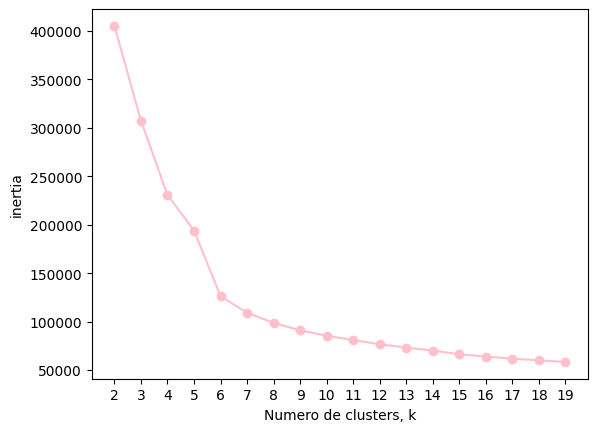

In [83]:
#Método del codo para encontrar la mejor cantidad de clusters: inertia
ks = range(2, 20) # crear valores del 2 al 19
inertias = []

for k in ks:
    # Crear  modelo
    model = KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=42)
    model.fit(Z)
    inertias.append(model.inertia_)

# Graficar cantidad de clusters vs inertias
plt.plot(ks, inertias, '-o', color = 'Pink')
plt.xlabel('Numero de clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

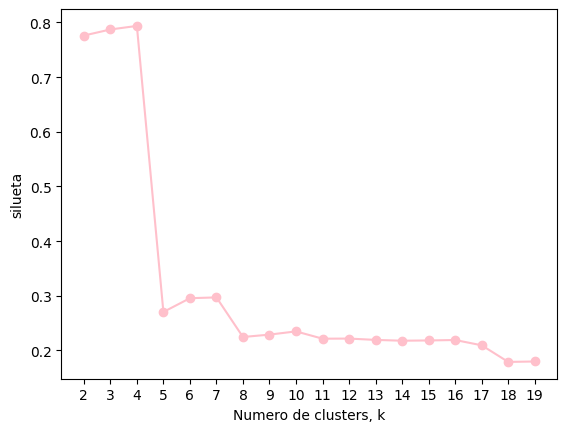

In [84]:
#Método de la rodilla: silueta
# sample_size: la silueta con las 17 160 filas compara todos los pares y tarda mucho;
# con una muestra fija de 5000 da casi lo mismo y es repetible
siluetas = []

for k in ks:
    # Crear  modelo
    model = KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=42)
    model.fit(Z)
    sil = metrics.silhouette_score(Z, model.labels_, sample_size=5000, random_state=0)
    siluetas.append(sil)

# Graficar cantidad de clusters vs silueta
plt.plot(ks, siluetas, '-o', color = 'Pink')
plt.xlabel('Numero de clusters, k')
plt.ylabel('silueta')
plt.xticks(ks)
plt.show()

In [85]:
#Creación de modelo de clustering con Kmeans
k = 6
model = KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=42)
model.fit(Z) #100% datos de calibración

KMeans(n_clusters=6, n_init=10, random_state=42)

In [86]:
#Evaluación
#Inertia: se require valor pequeño
print('Inercia o cohesión:', model.inertia_)

#Silueta: se requiere que sea positivo, ideal 0.5-1.0
sil = metrics.silhouette_score(Z, model.labels_, sample_size=5000, random_state=0)
print('Silueta:', sil)

Inercia o cohesión: 126268.33525262399
Silueta: 0.2955629771630766


In [87]:
#Centroides de los cluster como dataframe de pandas
# No hace falta des-normalizar: cada valor se lee como desviaciones respecto a lo normal
# de la última hora (0 = normal, +20 = muy por encima, -20 = muy por debajo)
centroides = pd.DataFrame(model.cluster_centers_, columns=Z.columns)
centroides.round(1)

,cpu_user,cpu_system,memoria_used,disco_used_frac,red_bytes_s,tasa_llamadas_pedidos,tasa_llamadas_catalogo
0,-0.6,-0.4,-0.3,0.2,-0.8,-0.8,-0.8
1,-0.0,0.0,-0.3,20.0,-0.1,-0.1,-0.1
2,0.1,0.3,20.0,0.1,-0.1,-0.0,-0.2
3,-3.2,-1.5,-13.0,-0.1,-9.3,-12.9,-16.9
4,0.7,0.6,-0.3,0.1,0.6,0.6,0.6
5,19.0,0.9,1.2,0.4,0.0,-0.0,-0.1


In [89]:
# Solución al error: Volver a cargar df correctamente en caso de haber sido sobrescrito por la función dropna
import pandas as pd
df = pd.read_csv('data.csv', parse_dates=['time'], index_col='time')

# Para interpretar en unidades reales: promedio de los valores originales en cada grupo
resultado = pd.DataFrame({'grupo': model.labels_}, index=Z.index).join(ref_z)
df.loc[Z.index, variables].groupby(resultado['grupo']).mean().round(4)

,cpu_user,cpu_system,memoria_used,disco_used_frac,red_bytes_s,tasa_llamadas_pedidos,tasa_llamadas_catalogo
grupo,,,,,,,
0,0.1408,0.0292,0.2139,0.1494,16410.7440,18.6556,37.3490
1,0.1803,0.0336,0.2137,0.6051,22869.4458,26.3450,52.6163
2,0.1384,0.0313,0.6985,0.1495,15828.7850,17.9329,35.8110
3,0.0880,0.0264,0.1872,0.1495,13678.8878,2.4402,0.3393
4,0.1676,0.0326,0.2137,0.1494,20817.4656,23.8998,47.5665
5,0.7193,0.0358,0.2171,0.1495,21185.0443,23.9025,47.6768


In [91]:
# 0. El modelo tiene que ser el de 6 grupos
assert model.n_clusters == 6, f"El modelo tiene {model.n_clusters} grupos; corre primero la celda de KMeans con k=6"

# 1. Nombres elegidos al interpretar los clusters (k=6, random_state=42).
#    Los grupos 0 y 4 son las dos mitades de la operación normal: llevan el mismo nombre,
#    así que quedan 5 perfiles
nombres = {
    0: "Operación normal",
    4: "Operación normal",
    5: "Saturación de CPU",
    2: "Saturación de memoria",
    1: "Disco en llenado",
    3: "Caída de servicio",
}

resultado = pd.DataFrame({'grupo': model.labels_}, index=Z.index)
resultado['perfil'] = resultado['grupo'].map(nombres)

# 2. Control: cada centroide con su nombre
print(pd.DataFrame(model.cluster_centers_, columns=Z.columns).round(1).rename(index=nombres))

# 3. Silueta de los 5 perfiles
sil_perfiles = metrics.silhouette_score(Z, resultado['perfil'], sample_size=5000, random_state=0)
print('Silueta de los 5 perfiles:', round(sil_perfiles, 3))   # ≈ 0,81

# 4. Las 7 variables con valores reales + el perfil, unidos por fecha y sin nulos
base = df.copy()
if 'time' in base.columns:
    base['time'] = pd.to_datetime(base['time'])
    base = base.set_index('time')

df_clustering = base[variables].join(resultado['perfil'], how='inner').dropna()
assert df_clustering['perfil'].notna().all() and len(df_clustering) > 0, "el perfil quedó vacío"
print(df_clustering.shape, '| nulos:', df_clustering.isna().sum().sum())
print(df_clustering['perfil'].value_counts())

# 5. Guardar y descargar
df_clustering.to_csv('df_clustering.csv')
from google.colab import files
files.download('df_clustering.csv')

                       cpu_user  cpu_system  memoria_used  disco_used_frac  \
Operación normal           -0.6        -0.4          -0.3              0.2   
Disco en llenado           -0.0         0.0          -0.3             20.0   
Saturación de memoria       0.1         0.3          20.0              0.1   
Caída de servicio          -3.2        -1.5         -13.0             -0.1   
Operación normal            0.7         0.6          -0.3              0.1   
Saturación de CPU          19.0         0.9           1.2              0.4   

                       red_bytes_s  tasa_llamadas_pedidos  \
Operación normal              -0.8                   -0.8   
Disco en llenado              -0.1                   -0.1   
Saturación de memoria         -0.1                   -0.0   
Caída de servicio             -9.3                  -12.9   
Operación normal               0.6                    0.6   
Saturación de CPU              0.0                   -0.0   

                       ta

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [92]:
from sklearn import metrics

orden = ['Operación normal', 'Saturación de CPU', 'Saturación de memoria',
         'Disco en llenado', 'Caída de servicio']

# 1. Centroides de los 5 perfiles, en desviaciones respecto a lo normal
#    (al unir los dos grupos normales, su centroide es el promedio de todos sus puntos)
centroides_5 = Z.groupby(resultado['perfil']).mean().reindex(orden)
print('Centroides de los 5 perfiles (0 = normal, +20 = muy por encima, -20 = muy por debajo):')
display(centroides_5.round(1))

# 2. Los mismos perfiles en unidades reales, para interpretarlos
base = df.copy()
if 'time' in base.columns:
    base['time'] = pd.to_datetime(base['time'])
    base = base.set_index('time')

centroides_5_reales = base.loc[Z.index, variables].groupby(resultado['perfil']).mean().reindex(orden)
centroides_5_reales['filas'] = resultado['perfil'].value_counts().reindex(orden)
print('Promedio de cada perfil en unidades reales:')
display(centroides_5_reales.round(3))

# 3. Silueta global de los 5 perfiles
sil = metrics.silhouette_score(Z, resultado['perfil'], sample_size=5000, random_state=0)
print('Silueta de los 5 perfiles:', round(sil, 3))

# 4. Silueta de cada perfil
sil_por_perfil = (pd.Series(metrics.silhouette_samples(Z, resultado['perfil']), index=Z.index)
                    .groupby(resultado['perfil']).mean().reindex(orden))
print('Silueta por perfil:')
print(sil_por_perfil.round(2))

Centroides de los 5 perfiles (0 = normal, +20 = muy por encima, -20 = muy por debajo):


,cpu_user,cpu_system,memoria_used,disco_used_frac,red_bytes_s,tasa_llamadas_pedidos,tasa_llamadas_catalogo
perfil,,,,,,,
Operación normal,0.1,0.1,-0.3,0.2,-0.1,-0.1,-0.1
Saturación de CPU,19.0,0.9,1.2,0.4,0.0,-0.0,-0.1
Saturación de memoria,0.1,0.3,20.0,0.1,-0.1,-0.0,-0.2
Disco en llenado,-0.0,0.0,-0.3,20.0,-0.1,-0.1,-0.1
Caída de servicio,-3.2,-1.5,-13.0,-0.1,-9.3,-12.9,-16.9


Promedio de cada perfil en unidades reales:


,cpu_user,cpu_system,memoria_used,disco_used_frac,red_bytes_s,tasa_llamadas_pedidos,tasa_llamadas_catalogo,filas
perfil,,,,,,,,
Operación normal,0.155,0.031,0.214,0.149,18702.943,21.383,42.664,15774
Saturación de CPU,0.719,0.036,0.217,0.150,21185.044,23.903,47.677,276
Saturación de memoria,0.138,0.031,0.699,0.150,15828.785,17.933,35.811,164
Disco en llenado,0.180,0.034,0.214,0.605,22869.446,26.345,52.616,834
Caída de servicio,0.088,0.026,0.187,0.150,13678.888,2.440,0.339,112


Silueta de los 5 perfiles: 0.809
Silueta por perfil:
perfil
Operación normal         0.81
Saturación de CPU        0.73
Saturación de memoria    0.82
Disco en llenado         0.84
Caída de servicio        0.37
dtype: float64


**Operación normal**	El servidor trabaja tranquilo: usa cerca del 16 % del procesador, el 21 % de la memoria y el 15 % del disco, y atiende unas 21 solicitudes por segundo en pedidos. Es como está el 92 % del tiempo.

**Saturación de CPU** El procesador se pone a trabajar al 72 %, casi cinco veces lo normal, sin que lleguen más solicitudes. Algo está consumiendo procesador de más.
Saturación de memoria	La memoria se llena hasta el 70 %, más del triple de lo normal, mientras todo lo demás sigue igual. Algo está ocupando memoria y no la suelta.

**Disco en llenado**	El disco pasa de estar al 15 % a estar en promedio al 61 % de su capacidad. El espacio se está agotando, de golpe o poco a poco.

**Caída de servicio**	Las solicitudes casi desaparecen: de unas 21 por segundo bajan a 2 en pedidos, y en catalogo prácticamente a cero. Uno de los servicios dejó de responder.